# 実験Ⅳ（個人ワーク）AIC最小化による基底数決定（基底展開重回帰）※Lasso無し

このノートブックは `example01_02.ipynb` と同じ流れ（線形重回帰 → 多項式基底展開 → AIC最小で次数決定 → 回帰式/図出力）を、配布サンプルデータに適用します。


In [143]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

plt.rcParams["axes.unicode_minus"] = False


In [144]:
!pip install japanize-matplotlib -q
%matplotlib inline

import warnings
warnings.simplefilter('ignore')  # 警告を無視（コメントアウト推奨）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib         # 日本語化 matplotlib
sns.set(font="IPAexGothic")       # 日本語フォント設定


In [145]:
# 文字化け対策（1つ目のコードセルは変更しない）
# 既存の sns.set(font="IPAexGothic") の後でフォント候補を上書きする
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'IPAexGothic', 'IPAGothic', 'Noto Sans CJK JP',
    'Yu Gothic', 'Meiryo', 'MS Gothic', 'TakaoGothic', 'DejaVu Sans'
]
plt.rcParams['axes.unicode_minus'] = False


## 1. データ読み込み

配布データのパスと列名を指定してください。

In [146]:
# ★課題データのパスを指定（例）
# Google Drive をマウント
from google.colab import drive
drive.mount('/content/drive')

# ---------------------------------------------------------
# ★ ファイルの保存場所に応じてパスを変更してください ★
#
#   例1: マイドライブ直下（デフォルト）
csv_path = '/content/drive/MyDrive/solar_dataset_3vars.csv'
#
#   例2: フォルダ内に置いた場合
#   csv_path = '/content/drive/MyDrive/データ/solar_dataset_3vars.csv'
#
#   例3: 共有ドライブの場合
#   csv_path = '/content/drive/Shareddrives/<ドライブ名>/solar_dataset_3vars.csv'
# ---------------------------------------------------------

import os
if os.path.exists(csv_path):
    print(f'✅ ファイルを確認しました: {csv_path}')
else:
    print(f'❌ ファイルが見つかりません: {csv_path}')
    print('   ・Drive 上のファイルパスを確認し，csv_path を修正してください')
    print('   ・左のファイルツリー（フォルダアイコン）で /content/drive/ 以下を確認できます')


# ★課題データの列名を指定
col_y  = "power_w"
col_x1 = "irradiance_wm2"
col_x2 = "module_temp_c"

df = pd.read_csv(csv_path)
df[[col_y, col_x1, col_x2]].head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ ファイルを確認しました: /content/drive/MyDrive/solar_dataset_3vars.csv


,power_w,irradiance_wm2,module_temp_c
0,18.771804,87.6,7.137500
1,36.287951,171.4,10.356250
2,63.745544,307.3,15.703125
3,76.473400,372.9,18.653125
4,60.249906,291.7,16.815625


## 2a. 線形重回帰モデル（回帰式）

In [147]:
reg_lin = LinearRegression()
reg_lin.fit(X, y)

b0 = float(reg_lin.intercept_)
b1 = float(reg_lin.coef_[0])
b2 = float(reg_lin.coef_[1])

y_pred_lin = reg_lin.predict(X)
mse_lin = mean_squared_error(y, y_pred_lin)

print("【2a】線形重回帰モデル")
print(f"MSE = {mse_lin:.6g}")
print("回帰式:")
print(f"y = {b0:.6e} + ({b1:.6e}) x1 + ({b2:.6e}) x2")

【2a】線形重回帰モデル
MSE = 5.89981
回帰式:
y = 1.013395e+01 + (1.882203e-01) x1 + (-3.155754e-01) x2


## 2b. 多項式基底展開重回帰モデル：AIC最小化で次数決定

In [148]:
def calc_aic_from_mse(mse: float, n: int, k: int) -> float:
    """example01_02.ipynb と同型のAIC計算。

    n: サンプル数
    k: 係数の数（基底展開後の特徴量数）
    ※ 切片は +1 で数える
    """
    return n * np.log(2 * np.pi * mse) + n + 2 * (k + 1)

# ★探索する最大次数（必要に応じて変更）
max_degree = 20
deg_list = np.arange(1, max_degree + 1)

n = X.shape[0]
aic_list = []
models = []

for deg in deg_list:
    phi = PolynomialFeatures(degree=int(deg), include_bias=False)
    model = make_pipeline(phi, LinearRegression())
    model.fit(X, y)

    yhat = model.predict(X)
    mse = mean_squared_error(y, yhat)

    k = int(model[0].n_output_features_)
    aic = float(calc_aic_from_mse(mse, n=n, k=k))

    aic_list.append(aic)
    models.append(model)
    print(f"deg = {deg}: AIC = {aic:.2e}")

aic_list = np.array(aic_list)
opt_idx = int(np.argmin(aic_list))
deg_opt = int(deg_list[opt_idx])
reg_opt = models[opt_idx]

print("\n【2b】AIC最小モデル")
print(f"AIC最小次数 degopt = {deg_opt}")
print(f"AIC最小値 = {aic_list[opt_idx]:.6e}")

deg = 1: AIC = 1.21e+04
deg = 2: AIC = -1.31e+05
deg = 3: AIC = -1.32e+05
deg = 4: AIC = -3.22e+04
deg = 5: AIC = 7.34e+03
deg = 6: AIC = 1.28e+04
deg = 7: AIC = 1.65e+04
deg = 8: AIC = 1.88e+04
deg = 9: AIC = 2.05e+04
deg = 10: AIC = 2.17e+04
deg = 11: AIC = 2.25e+04
deg = 12: AIC = 2.31e+04
deg = 13: AIC = 2.48e+04
deg = 14: AIC = 2.51e+04
deg = 15: AIC = 2.54e+04
deg = 16: AIC = 2.56e+04
deg = 17: AIC = 2.58e+04
deg = 18: AIC = 2.60e+04
deg = 19: AIC = 2.62e+04
deg = 20: AIC = 2.64e+04

【2b】AIC最小モデル
AIC最小次数 degopt = 3
AIC最小値 = -1.322393e+05


## 基底展開重回帰式（AIC最小次数の回帰式）

In [149]:
# 多項式基底名（x1, x2 の項名）
feature_names = reg_opt[0].get_feature_names_out(["x1", "x2"])
w0 = float(reg_opt[-1].intercept_)
ws = reg_opt[-1].coef_.ravel()

terms = [f"{w0:.6e}"] + [f"({ws[i]:.6e}){feature_names[i]}" for i in range(len(ws))]
eq = "y = " + " + ".join(terms)

print("基底展開重回帰式:")
print(eq)

# 参考: 適合誤差
yhat_opt = reg_opt.predict(X)
mse_opt = mean_squared_error(y, yhat_opt)
print(f"\nMSE(opt) = {mse_opt:.6g}")

基底展開重回帰式:
y = 2.955858e-12 + (2.200000e-01)x1 + (-4.031583e-15)x2 + (5.556016e-17)x1^2 + (-8.000000e-04)x1 x2 + (1.178004e-16)x2^2 + (7.457860e-21)x1^3 + (-1.779909e-18)x1^2 x2 + (2.476560e-17)x1 x2^2 + (-1.435820e-17)x2^3

MSE(opt) = 8.62428e-24


## AICのプロット

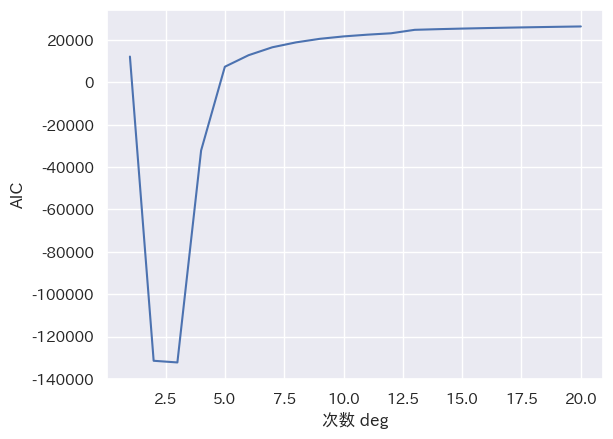

In [150]:
fig, ax = plt.subplots()
ax.plot(deg_list, aic_list)
ax.set_xlabel("次数 deg")
ax.set_ylabel("AIC")
ax.grid(True)
plt.show()

### 図６　観測データ（三次元散布図）

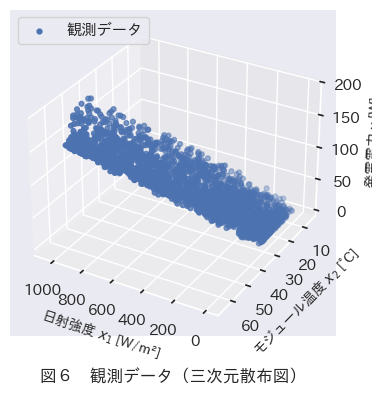

In [151]:
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.scatter(x1, x2, y, color='#4C72B0', s=12, label='観測データ')
ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.1, '図６　観測データ（三次元散布図）', transform=ax.transAxes, ha='center', va='top')

minx1, maxx1 = x1.min(), x1.max()
minx2, maxx2 = x2.min(), x2.max()
rx1 = maxx1 - minx1
rx2 = maxx2 - minx2
ax.set_xlim([minx1 - 0.1 * rx1, maxx1 + 0.1 * rx1])
ax.set_ylim([minx2 - 0.1 * rx2, maxx2 + 0.1 * rx2])

ax.view_init(elev=30, azim=120)
ax.grid(True)
ax.legend(loc='upper left')

plt.subplots_adjust(bottom=0.2)
plt.show()

### 図７　線形重回帰分析の結果

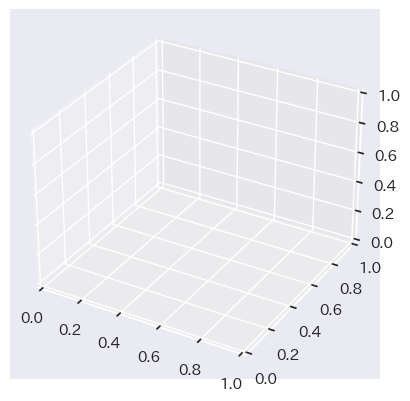

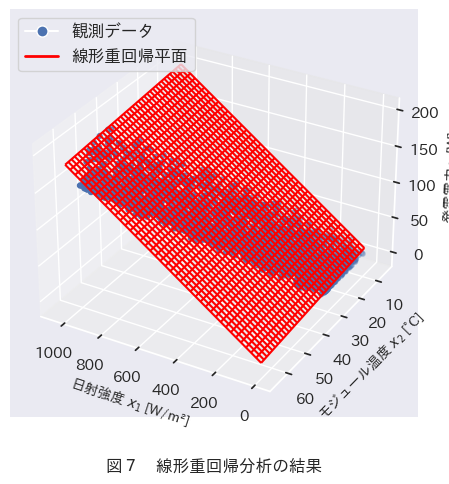

In [152]:
nPoints = 40
minx1, maxx1 = x1.min(), x1.max()
minx2, maxx2 = x2.min(), x2.max()
rx1 = maxx1 - minx1
rx2 = maxx2 - minx2

xfit1, xfit2 = np.meshgrid(
    np.linspace(minx1, maxx1, nPoints),
    np.linspace(minx2, maxx2, nPoints)
)
Xfit = np.concatenate([xfit1.reshape(-1, 1), xfit2.reshape(-1, 1)], axis=1)
yfit_lin = reg_lin.predict(Xfit).reshape(xfit1.shape)

ax = plt.axes(projection='3d')
fig = plt.figure(figsize=(7.0, 6.0))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1, x2, y, color='#4C72B0', s=12)
ax.plot_wireframe(xfit1, xfit2, yfit_lin, color='red')
ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.1, '図７　線形重回帰分析の結果', transform=ax.transAxes, ha='center', va='top')

ax.set_xlim([minx1 - 0.1 * rx1, maxx1 + 0.1 * rx1])
ax.set_ylim([minx2 - 0.1 * rx2, maxx2 + 0.1 * rx2])

ax.view_init(elev=30, azim=120)
ax.grid(True)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='観測データ'),
    Line2D([0], [0], color='red', lw=2, label='線形重回帰平面')
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=12)

plt.subplots_adjust(bottom=0.2)
plt.show()

### 図８　基底展開重回帰分析の結果

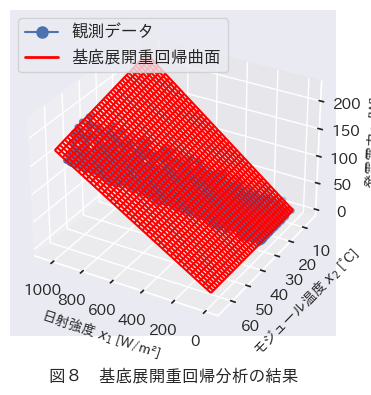

In [153]:
nPoints = 40
minx1, maxx1 = x1.min(), x1.max()
minx2, maxx2 = x2.min(), x2.max()
rx1 = maxx1 - minx1
rx2 = maxx2 - minx2

xfit1, xfit2 = np.meshgrid(
    np.linspace(minx1, maxx1, nPoints),
    np.linspace(minx2, maxx2, nPoints)
)
Xfit = np.concatenate([xfit1.reshape(-1, 1), xfit2.reshape(-1, 1)], axis=1)
yfit_basis = reg_opt.predict(Xfit).reshape(xfit1.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1, x2, y, color='#4C72B0', s=12)
ax.plot_wireframe(xfit1, xfit2, yfit_basis, color='red')
ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.1, '図８　基底展開重回帰分析の結果', transform=ax.transAxes, ha='center', va='top')

ax.set_xlim([minx1 - 0.1 * rx1, maxx1 + 0.1 * rx1])
ax.set_ylim([minx2 - 0.1 * rx2, maxx2 + 0.1 * rx2])

ax.view_init(elev=30, azim=120)
ax.grid(True)

legend_handles = [
    Line2D([0], [0], marker='o', color='#4C72B0', markerfacecolor='#4C72B0', markersize=8, label='観測データ'),
    Line2D([0], [0], color='red', lw=2, label='基底展開重回帰曲面'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=12)

plt.subplots_adjust(bottom=0.2)
plt.show()

### 図１５　線形重回帰分析と基底展開重回帰分析の重ね描き

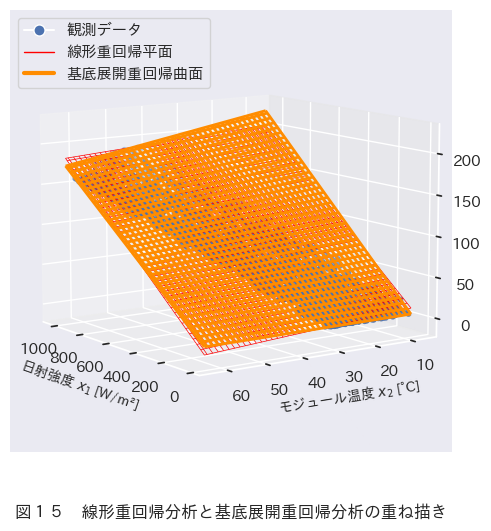

In [154]:
nPoints = 80
minx1, maxx1 = x1.min(), x1.max()
minx2, maxx2 = x2.min(), x2.max()
rx1 = maxx1 - minx1
rx2 = maxx2 - minx2

xfit1, xfit2 = np.meshgrid(
    np.linspace(minx1, maxx1, nPoints),
    np.linspace(minx2, maxx2, nPoints)
)
Xfit = np.concatenate([xfit1.reshape(-1, 1), xfit2.reshape(-1, 1)], axis=1)

yfit_lin_b = reg_lin.predict(Xfit).reshape(xfit1.shape)
yfit_basis_b = reg_opt.predict(Xfit).reshape(xfit1.shape)

fig = plt.figure(figsize=(9, 6.5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1, x2, y, color='#4C72B0', s=10, label='観測データ')
ax.plot_wireframe(xfit1, xfit2, yfit_lin_b, color='red', linewidth=0.5, label='線形重回帰平面')
ax.plot_wireframe(xfit1, xfit2, yfit_basis_b, color='darkorange', linewidth=2.0, label='基底展開重回帰曲面')

ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.12, '図１５　線形重回帰分析と基底展開重回帰分析の重ね描き',
          transform=ax.transAxes, ha='center', va='top')

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='観測データ'),
    Line2D([0], [0], color='red', lw=1, label='線形重回帰平面'),
    Line2D([0], [0], color='darkorange', lw=3, label='基底展開重回帰曲面')
]
ax.legend(handles=legend_handles, loc='upper left')

ax.view_init(elev=10, azim=145)
plt.subplots_adjust(bottom=0.2)
plt.show()